<a href="https://colab.research.google.com/github/toushif007/website/blob/main/Copy_of_water_potability_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("water_potability.csv")
print(df)

            ph    Hardness        Solids  Chloramines     Sulfate  \
0          NaN  204.890455  20791.318981     7.300212  368.516441   
1     3.716080  129.422921  18630.057858     6.635246         NaN   
2     8.099124  224.236259  19909.541732     9.275884         NaN   
3     8.316766  214.373394  22018.417441     8.059332  356.886136   
4     9.092223  181.101509  17978.986339     6.546600  310.135738   
...        ...         ...           ...          ...         ...   
3271  4.668102  193.681735  47580.991603     7.166639  359.948574   
3272  7.808856  193.553212  17329.802160     8.061362         NaN   
3273  9.419510  175.762646  33155.578218     7.350233         NaN   
3274  5.126763  230.603758  11983.869376     6.303357         NaN   
3275  7.874671  195.102299  17404.177061     7.509306         NaN   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       564.308654       10.379783        86.990970   2.963135           0  
1       592.88535

Dataset Shape: (3276, 10)

Missing Values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Class Distribution After SMOTE:
Potability
0.0    1998
1.0    1998
Name: count, dtype: int64

Training Logistic Regression...

===== LOGISTIC REGRESSION =====
Accuracy: 52.5 %
[[207 193]
 [187 213]]
              precision    recall  f1-score   support

         0.0       0.53      0.52      0.52       400
         1.0       0.52      0.53      0.53       400

    accuracy                           0.53       800
   macro avg       0.53      0.52      0.52       800
weighted avg       0.53      0.53      0.52       800


Training SVM...

Best SVM Parameters:
{'C': 10, 'kernel': 'rbf'}

===== SVM =====
Accuracy: 65.25 %
[[260 140]
 [138 262]]
              precision    recall  f1-score   support

        

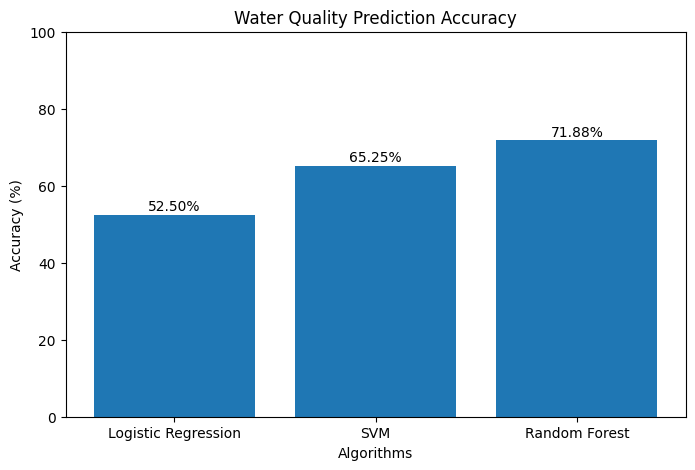

In [ ]:
# WATER QUALITY PREDICTION USING MACHINE LEARNING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("water_potability.csv")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

imputer = SimpleImputer(strategy='mean')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# ==========================================
# FEATURES AND TARGET
# ==========================================

X = df.drop("Potability", axis=1)
y = df["Potability"]

# ==========================================
# BALANCE DATASET USING SMOTE
# ==========================================

smote = SMOTE(random_state=42)

X, y = smote.fit_resample(X, y)

print("\nClass Distribution After SMOTE:")
print(pd.Series(y).value_counts())

# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# LOGISTIC REGRESSION
# ==========================================

print("\nTraining Logistic Regression...")

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy:", round(lr_acc * 100, 2), "%")
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# ==========================================
# SVM
# ==========================================

print("\nTraining SVM...")

svm_parameters = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(
    SVC(),
    svm_parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_

svm_pred = best_svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("\nBest SVM Parameters:")
print(svm_grid.best_params_)

print("\n===== SVM =====")
print("Accuracy:", round(svm_acc * 100, 2), "%")
print(confusion_matrix(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

# ==========================================
# RANDOM FOREST
# ==========================================

print("\nTraining Random Forest...")

rf_parameters = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)

print("\n===== RANDOM FOREST =====")
print("Accuracy:", round(rf_acc * 100, 2), "%")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# ==========================================
# MODEL COMPARISON
# ==========================================

print("\n===================================")
print("MODEL COMPARISON")
print("===================================")

print("Logistic Regression :", round(lr_acc * 100, 2), "%")
print("SVM                 :", round(svm_acc * 100, 2), "%")
print("Random Forest       :", round(rf_acc * 100, 2), "%")

best_accuracy = max(lr_acc, svm_acc, rf_acc)

if best_accuracy == lr_acc:
    print("\nBest Model : Logistic Regression")
elif best_accuracy == svm_acc:
    print("\nBest Model : SVM")
else:
    print("\nBest Model : Random Forest")

# ==========================================
# ACCURACY GRAPH
# ==========================================

models = [
    "Logistic Regression",
    "SVM",
    "Random Forest"
]

accuracies = [
    lr_acc * 100,
    svm_acc * 100,
    rf_acc * 100
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

plt.title("Water Quality Prediction Accuracy")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}%",
        ha='center'
    )

plt.ylim(0, 100)

plt.show()

WATER QUALITY PREDICTION

Dataset Shape: (3276, 10)

MODEL PERFORMANCE
Accuracy : 62.8 %

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656


WATER QUALITY PREDICTION

Input Values:
pH              : 7.0
Hardness        : 200.0
Solids          : 18000.0
Chloramines     : 7.0
Sulfate         : 320.0
Conductivity    : 400.0
Organic Carbon  : 12.0
Trihalomethanes : 60.0
Turbidity       : 4.0

Prediction Result : NOT SAFE TO DRINK

Prediction Probability
Not Safe : 60.54 %
Safe     : 39.46 %


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/u

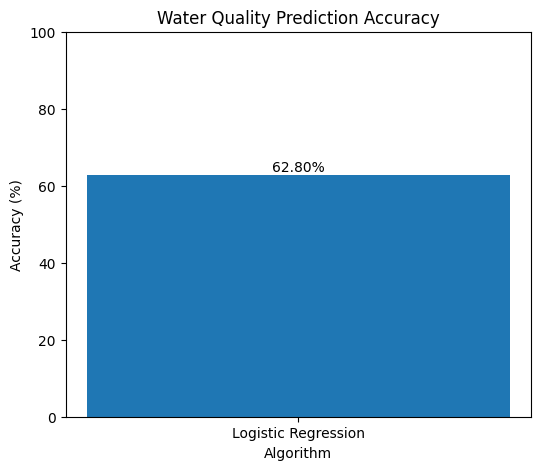


Program Executed Successfully!


In [ ]:
# ==========================================================
# WATER QUALITY PREDICTION USING LOGISTIC REGRESSION
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("water_potability.csv")

print("=" * 50)
print("WATER QUALITY PREDICTION")
print("=" * 50)

print("\nDataset Shape:", df.shape)

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

imputer = SimpleImputer(strategy='mean')

df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# ==========================================================
# FEATURES AND TARGET
# ==========================================================

X = df.drop("Potability", axis=1)
y = df["Potability"]

# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# ==========================================================
# SPLIT DATA
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# TRAIN LOGISTIC REGRESSION MODEL
# ==========================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# ==========================================================
# TESTING
# ==========================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print("Accuracy :", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# SAMPLE WATER DATA FOR PREDICTION
# ==========================================================

sample_data = [[
    7.0,      # pH
    200.0,    # Hardness
    18000.0,  # Solids
    7.0,      # Chloramines
    320.0,    # Sulfate
    400.0,    # Conductivity
    12.0,     # Organic Carbon
    60.0,     # Trihalomethanes
    4.0       # Turbidity
]]

# ==========================================================
# SCALE SAMPLE DATA
# ==========================================================

sample_scaled = scaler.transform(sample_data)

# ==========================================================
# PREDICTION
# ==========================================================

prediction = model.predict(sample_scaled)

probability = model.predict_proba(sample_scaled)

print("\n===================================")
print("WATER QUALITY PREDICTION")
print("===================================")

print("\nInput Values:")
print("pH              :", sample_data[0][0])
print("Hardness        :", sample_data[0][1])
print("Solids          :", sample_data[0][2])
print("Chloramines     :", sample_data[0][3])
print("Sulfate         :", sample_data[0][4])
print("Conductivity    :", sample_data[0][5])
print("Organic Carbon  :", sample_data[0][6])
print("Trihalomethanes :", sample_data[0][7])
print("Turbidity       :", sample_data[0][8])

if prediction[0] == 1:
    print("\nPrediction Result : SAFE TO DRINK")
else:
    print("\nPrediction Result : NOT SAFE TO DRINK")

print("\nPrediction Probability")
print("Not Safe :", round(probability[0][0] * 100, 2), "%")
print("Safe     :", round(probability[0][1] * 100, 2), "%")

# ==========================================================
# ACCURACY GRAPH
# ==========================================================

plt.figure(figsize=(6, 5))

plt.bar(
    ["Logistic Regression"],
    [accuracy * 100]
)

plt.title("Water Quality Prediction Accuracy")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.show()

print("\nProgram Executed Successfully!")

WATER QUALITY PREDICTION

Dataset Shape: (3276, 10)

MODEL PERFORMANCE
Accuracy : 69.51 %

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.92      0.79       412
           1       0.69      0.32      0.44       244

    accuracy                           0.70       656
   macro avg       0.69      0.62      0.62       656
weighted avg       0.69      0.70      0.66       656


WATER QUALITY PREDICTION

Input Values:
pH              : 7.0
Hardness        : 200.0
Solids          : 18000.0
Chloramines     : 7.0
Sulfate         : 320.0
Conductivity    : 400.0
Organic Carbon  : 12.0
Trihalomethanes : 60.0
Turbidity       : 4.0

Prediction Result : NOT SAFE TO DRINK

Prediction Probability
Not Safe : 72.33 %
Safe     : 27.67 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


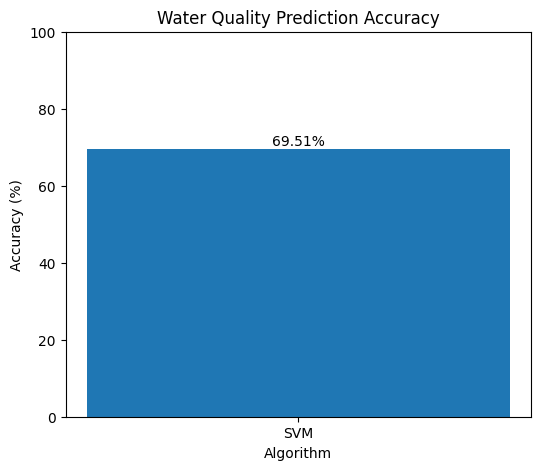


Program Executed Successfully!


In [ ]:
# ==========================================================
# WATER QUALITY PREDICTION USING SVM
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("water_potability.csv")

print("=" * 50)
print("WATER QUALITY PREDICTION")
print("=" * 50)

print("\nDataset Shape:", df.shape)

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

imputer = SimpleImputer(strategy='mean')

df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# ==========================================================
# FEATURES AND TARGET
# ==========================================================

X = df.drop("Potability", axis=1)
y = df["Potability"]

# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# ==========================================================
# SPLIT DATA
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# TRAIN SVM MODEL
# ==========================================================

model = SVC(
    kernel='rbf',
    probability=True
)

model.fit(X_train, y_train)

# ==========================================================
# TESTING
# ==========================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print("Accuracy :", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# SAMPLE WATER DATA FOR PREDICTION
# ==========================================================

sample_data = [[
    7.0,      # pH
    200.0,    # Hardness
    18000.0,  # Solids
    7.0,      # Chloramines
    320.0,    # Sulfate
    400.0,    # Conductivity
    12.0,     # Organic Carbon
    60.0,     # Trihalomethanes
    4.0       # Turbidity
]]

# ==========================================================
# SCALE SAMPLE DATA
# ==========================================================

sample_scaled = scaler.transform(sample_data)

# ==========================================================
# PREDICTION
# ==========================================================

prediction = model.predict(sample_scaled)

probability = model.predict_proba(sample_scaled)

print("\n===================================")
print("WATER QUALITY PREDICTION")
print("===================================")

print("\nInput Values:")
print("pH              :", sample_data[0][0])
print("Hardness        :", sample_data[0][1])
print("Solids          :", sample_data[0][2])
print("Chloramines     :", sample_data[0][3])
print("Sulfate         :", sample_data[0][4])
print("Conductivity    :", sample_data[0][5])
print("Organic Carbon  :", sample_data[0][6])
print("Trihalomethanes :", sample_data[0][7])
print("Turbidity       :", sample_data[0][8])

if prediction[0] == 1:
    print("\nPrediction Result : SAFE TO DRINK")
else:
    print("\nPrediction Result : NOT SAFE TO DRINK")

print("\nPrediction Probability")
print("Not Safe :", round(probability[0][0] * 100, 2), "%")
print("Safe     :", round(probability[0][1] * 100, 2), "%")

# ==========================================================
# ACCURACY GRAPH
# ==========================================================

plt.figure(figsize=(6, 5))

plt.bar(
    ["SVM"],
    [accuracy * 100]
)

plt.title("Water Quality Prediction Accuracy")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.show()

print("\nProgram Executed Successfully!")

WATER QUALITY PREDICTION

Dataset Shape: (3276, 10)

MODEL PERFORMANCE
Accuracy : 67.84 %

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       412
           1       0.61      0.38      0.47       244

    accuracy                           0.68       656
   macro avg       0.65      0.62      0.62       656
weighted avg       0.67      0.68      0.66       656


WATER QUALITY PREDICTION

Input Values:
pH              : 7.0
Hardness        : 200.0
Solids          : 18000.0
Chloramines     : 7.0
Sulfate         : 320.0
Conductivity    : 400.0
Organic Carbon  : 12.0
Trihalomethanes : 60.0
Turbidity       : 4.0

Prediction Result : NOT SAFE TO DRINK

Prediction Probability
Not Safe : 60.0 %
Safe     : 40.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


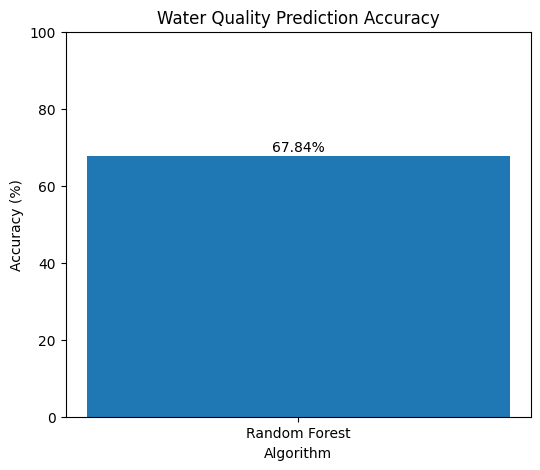


Program Executed Successfully!


In [ ]:
# ==========================================================
# WATER QUALITY PREDICTION USING RANDOM FOREST
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("water_potability.csv")

print("=" * 50)
print("WATER QUALITY PREDICTION")
print("=" * 50)

print("\nDataset Shape:", df.shape)

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

imputer = SimpleImputer(strategy='mean')

df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# ==========================================================
# FEATURES AND TARGET
# ==========================================================

X = df.drop("Potability", axis=1)
y = df["Potability"]

# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# ==========================================================
# SPLIT DATA
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# TRAIN RANDOM FOREST MODEL
# ==========================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================================
# TESTING
# ==========================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print("Accuracy :", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# SAMPLE WATER DATA FOR PREDICTION
# ==========================================================

sample_data = [[
    7.0,      # pH
    200.0,    # Hardness
    18000.0,  # Solids
    7.0,      # Chloramines
    320.0,    # Sulfate
    400.0,    # Conductivity
    12.0,     # Organic Carbon
    60.0,     # Trihalomethanes
    4.0       # Turbidity
]]

# ==========================================================
# SCALE SAMPLE DATA
# ==========================================================

sample_scaled = scaler.transform(sample_data)

# ==========================================================
# PREDICTION
# ==========================================================

prediction = model.predict(sample_scaled)

probability = model.predict_proba(sample_scaled)

print("\n===================================")
print("WATER QUALITY PREDICTION")
print("===================================")

print("\nInput Values:")
print("pH              :", sample_data[0][0])
print("Hardness        :", sample_data[0][1])
print("Solids          :", sample_data[0][2])
print("Chloramines     :", sample_data[0][3])
print("Sulfate         :", sample_data[0][4])
print("Conductivity    :", sample_data[0][5])
print("Organic Carbon  :", sample_data[0][6])
print("Trihalomethanes :", sample_data[0][7])
print("Turbidity       :", sample_data[0][8])

if prediction[0] == 1:
    print("\nPrediction Result : SAFE TO DRINK")
else:
    print("\nPrediction Result : NOT SAFE TO DRINK")

print("\nPrediction Probability")
print("Not Safe :", round(probability[0][0] * 100, 2), "%")
print("Safe     :", round(probability[0][1] * 100, 2), "%")

# ==========================================================
# ACCURACY GRAPH
# ==========================================================

plt.figure(figsize=(6, 5))

plt.bar(
    ["Random Forest"],
    [accuracy * 100]
)

plt.title("Water Quality Prediction Accuracy")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.show()

print("\nProgram Executed Successfully!")


========== MODEL ACCURACY ==========
Logistic Regression : 62.8 %
SVM                 : 69.51 %
Random Forest       : 67.84 %

Best Model: SVM

========== PREDICTION ==========
Water is NOT SAFE TO DRINK


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


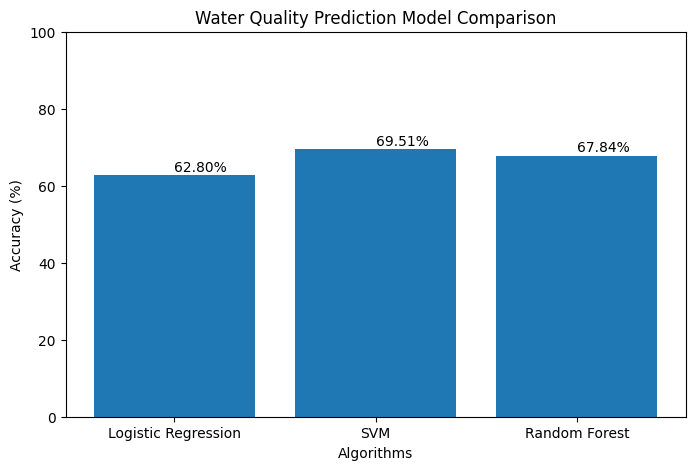

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("water_potability.csv")

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

imputer = SimpleImputer(strategy='mean')
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# ==========================================================
# FEATURES AND TARGET
# ==========================================================

X = df.drop("Potability", axis=1)
y = df["Potability"]

# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# ==========================================================
# SVM
# ==========================================================

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

# ==========================================================
# RANDOM FOREST
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# ==========================================================
# ACCURACY RESULTS
# ==========================================================

print("\n========== MODEL ACCURACY ==========")

print("Logistic Regression :", round(lr_acc * 100, 2), "%")
print("SVM                 :", round(svm_acc * 100, 2), "%")
print("Random Forest       :", round(rf_acc * 100, 2), "%")

# ==========================================================
# BEST MODEL
# ==========================================================

accuracies = {
    "Logistic Regression": lr_acc,
    "SVM": svm_acc,
    "Random Forest": rf_acc
}

best_model_name = max(accuracies, key=accuracies.get)

print("\nBest Model:", best_model_name)

if best_model_name == "Logistic Regression":
    best_model = lr
elif best_model_name == "SVM":
    best_model = svm
else:
    best_model = rf

# ==========================================================
# SAMPLE DATA FOR PREDICTION
# ==========================================================

sample_data = [[
    7.0,
    200.0,
    18000.0,
    7.0,
    320.0,
    400.0,
    12.0,
    60.0,
    4.0
]]

sample_scaled = scaler.transform(sample_data)

prediction = best_model.predict(sample_scaled)

print("\n========== PREDICTION ==========")

if prediction[0] == 1:
    print("Water is SAFE TO DRINK")
else:
    print("Water is NOT SAFE TO DRINK")

# ==========================================================
# COMPARISON GRAPH
# ==========================================================

models = [
    "Logistic Regression",
    "SVM",
    "Random Forest"
]

acc = [
    lr_acc * 100,
    svm_acc * 100,
    rf_acc * 100
]

plt.figure(figsize=(8, 5))
plt.bar(models, acc)

plt.title("Water Quality Prediction Model Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")

for i, v in enumerate(acc):
    plt.text(i, v + 1, f"{v:.2f}%")

plt.ylim(0, 100)
plt.show()